
# AEGIS-RS Fog Module: FFA-Net Training on RTTS

This notebook builds a research-oriented fog pipeline around **FFA-Net** for dehazing, then reports:
- Dehazing metrics: PSNR, SSIM, MSE
- Classification metrics: Accuracy, Precision, Recall, F1
- Optional detection metrics: IoU, AP, mAP (if YOLO predictions are provided)
- System metrics: FPS and latency

## Core Formulas Used

1. Atmospheric model: $I(x)=J(x)t(x)+A(1-t(x))$
2. Transmission: $t(x)=e^{-\beta d(x)}$
3. Reconstruction: $J(x)=\frac{I(x)-A}{t(x)}+A$
4. Convolution: $Z=W*X+b$
5. ReLU: $f(x)=\max(0,x)$
6. IoU: $IoU=\frac{|B\cap G|}{|B\cup G|}$
7. Sigmoid: $P=\frac{1}{1+e^{-x}}$
8. Cross-entropy: $L=-\sum y\log(\hat{y})$
9. PSNR: $PSNR=10\log_{10}(MAX^2/MSE)$
10. Risk score: $R=w_1F+w_2H+w_3T+w_4V^{-1}$

In [1]:
# ============================================================================
# CUDA ENVIRONMENT SETUP (xgboost_fog/venv)
# ============================================================================
# VENV READY: A dedicated Python 3.12 venv with CUDA 12.1 PyTorch is pre-configured
# at: RTTS/xgboost_fog/venv
#
# TO USE THIS NOTEBOOK:
# 1. Select Kernel: Click 'Select Kernel' → Choose 'Python 3.12.x (xgboost_fog/venv)'
# 2. Run all cells below - CUDA verification will run automatically
#
# IF REINSTALLING (optional):
# Uncomment and run these lines in a terminal from xgboost_fog/ directory:
# python -m venv venv
# .\venv\Scripts\python.exe -m pip install --upgrade pip
# .\venv\Scripts\python.exe -m pip install -r requirements.txt 
# .\venv\Scripts\python.exe -m pip install torch==2.5.1 torchvision==0.20.1 torchaudio==2.5.1 --index-url https://download.pytorch.org/whl/cu121
# ============================================================================

import json
import math
import random
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print('='*70)
print('CUDA ENVIRONMENT VERIFICATION')
print('='*70)
print('Torch version:', torch.__version__)
print('Torch CUDA build:', torch.version.cuda)

# STRICT CUDA REQUIREMENT: Fail if CPU-only build is loaded
if '+cpu' in torch.__version__ or torch.version.cuda is None:
    raise RuntimeError(
        'ERROR: This kernel is using a CPU-only torch build.\n'
        'To fix: Restart the notebook kernel, then select the correct kernel:\n'
        '  Select Kernel → Choose "Python 3.12.x (xgboost_fog/venv)"\n'
        'Ensure RTTS/xgboost_fog/venv/Scripts/python.exe is the active interpreter.'
    )

torch.backends.cudnn.benchmark = True
if not torch.cuda.is_available():
    raise RuntimeError(
        'ERROR: CUDA is not available to this kernel.\n'
        'Check: NVIDIA driver, CUDA runtime, and GPU availability.\n'
        'Then restart the notebook kernel and try again.'
    )

DEVICE = torch.device('cuda')
print('Device:', DEVICE)
print('GPU:', torch.cuda.get_device_name(0))
print('='*70)
print('✓ CUDA environment ready for fog detection training')

e:\Anaconda\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
e:\Anaconda\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


CUDA ENVIRONMENT VERIFICATION
Torch version: 2.5.1+cu121
Torch CUDA build: 12.1
Device: cuda
GPU: NVIDIA GeForce RTX 3070 Laptop GPU
✓ CUDA environment ready for fog detection training


In [2]:
# Paths aligned to your workspace
RTTS_ROOT = Path('..').resolve()
JPEG_DIR = RTTS_ROOT / 'JPEGImages'
SPLIT_FILE = RTTS_ROOT / 'ImageSets' / 'Main' / 'test.txt'

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
BATCH_SIZE = 8
EPOCHS = 25  # Increased from 8
LR = 2e-4    # Slightly increased initial LR
VAL_RATIO = 0.15

print('RTTS root:', RTTS_ROOT)
print('Split file:', SPLIT_FILE)

RTTS root: E:\6th SEM Data\Projects\AEGIS-RS_IDP\RTTS
Split file: E:\6th SEM Data\Projects\AEGIS-RS_IDP\RTTS\ImageSets\Main\test.txt


In [3]:
def load_ids(split_file: Path) -> List[str]:
    ids = []
    with split_file.open('r', encoding='utf-8') as f:
        for line in f:
            v = line.strip()
            if v:
                ids.append(v)
    return ids

def read_rgb(path: Path) -> np.ndarray:
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f'Image not found: {path}')
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def pseudo_clean_from_fog(rgb: np.ndarray) -> np.ndarray:
    # Improved target: CLAHE + gamma + slight contrast boost
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    l2 = clahe.apply(l)
    out = cv2.cvtColor(cv2.merge([l2, a, b]), cv2.COLOR_LAB2RGB).astype(np.float32) / 255.0
    gamma = 1.15
    out = np.power(np.clip(out, 1e-6, 1.0), 1.0 / gamma)
    # Slight contrast boost
    out = (out - 0.5) * 1.1 + 0.5
    return np.clip(out, 0.0, 1.0)

def synthesize_fog(clean: np.ndarray, beta_range=(0.4, 1.8), depth_variation=True) -> Tuple[np.ndarray, float]:
    h, w, _ = clean.shape
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    
    if depth_variation:
        # More realistic depth: Gaussian center with variation
        cy, cx = h * 0.4 + np.random.uniform(-50, 50), w * 0.5 + np.random.uniform(-50, 50)
        dy = (yy - cy) / max(h, 1)
        dx = (xx - cx) / max(w, 1)
        depth = np.exp(-(dy**2 + dx**2) / 0.3) * 0.6 + 0.4
    else:
        depth = (1.0 - yy / max(h - 1, 1))
        depth = 0.2 + 0.8 * depth

    beta = float(np.random.uniform(*beta_range))
    t = np.exp(-beta * depth)[..., None]
    
    # More varied airlight
    A = np.random.uniform(0.65, 0.95, size=(1, 1, 3)).astype(np.float32)
    foggy = clean * t + A * (1.0 - t)
    return np.clip(foggy, 0.0, 1.0), beta

def beta_to_fog_class(beta: float) -> int:
    # Better class separation
    if beta < 0.75:
        return 0
    if beta < 1.25:
        return 1
    return 2

ids = load_ids(SPLIT_FILE)
paths = [JPEG_DIR / f'{x}.png' for x in ids if (JPEG_DIR / f'{x}.png').exists()]
random.shuffle(paths)
split_idx = int(len(paths) * (1 - VAL_RATIO))
train_paths = paths[:split_idx]
val_paths = paths[split_idx:]

print(f'Total images: {len(paths)} | Train: {len(train_paths)} | Val: {len(val_paths)}')

Total images: 4322 | Train: 3673 | Val: 649


In [4]:
class RTTSFogPairs(Dataset):
    def __init__(self, image_paths: List[Path], img_size: int = 256, is_train: bool = False):
        self.image_paths = image_paths
        self.img_size = img_size
        self.is_train = is_train
        self.to_tensor = transforms.ToTensor()

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        p = self.image_paths[idx]
        rgb = read_rgb(p)
        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

        # Data augmentation for training
        if self.is_train:
            # Random horizontal flip
            if np.random.rand() > 0.5:
                rgb = cv2.flip(rgb, 1)
            # Random rotation (small)
            if np.random.rand() > 0.6:
                angle = np.random.uniform(-10, 10)
                center = (self.img_size // 2, self.img_size // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                rgb = cv2.warpAffine(rgb, M, (self.img_size, self.img_size))
            # Random brightness
            if np.random.rand() > 0.5:
                brightness = np.random.uniform(0.9, 1.1)
                rgb = np.clip(rgb.astype(np.float32) * brightness, 0, 255).astype(np.uint8)
            # Random noise
            if np.random.rand() > 0.7:
                noise = np.random.normal(0, 5, rgb.shape)
                rgb = np.clip(rgb.astype(np.float32) + noise, 0, 255).astype(np.uint8)

        clean = pseudo_clean_from_fog(rgb)
        foggy, beta = synthesize_fog(clean, depth_variation=self.is_train)

        x = torch.from_numpy(foggy.transpose(2, 0, 1)).float()
        y = torch.from_numpy(clean.transpose(2, 0, 1)).float()
        fog_cls = beta_to_fog_class(beta)

        return x, y, torch.tensor(fog_cls, dtype=torch.long), torch.tensor(beta, dtype=torch.float32)

train_ds = RTTSFogPairs(train_paths, IMG_SIZE, is_train=True)
val_ds = RTTSFogPairs(val_paths, IMG_SIZE, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb, cb, bb = next(iter(train_loader))
print(xb.shape, yb.shape, cb.shape, bb.shape)

torch.Size([8, 3, 256, 256]) torch.Size([8, 3, 256, 256]) torch.Size([8]) torch.Size([8])


In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_c, out_c, k=3, s=1, p=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, k, s, p),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, k, 1, p),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

class FFAInspiredNet(nn.Module):
    # Enhanced FFA-inspired network with better classification head
    def __init__(self, base=48):
        super().__init__()
        self.head = nn.Sequential(
            nn.Conv2d(3, base, 3, 1, 1),
            nn.BatchNorm2d(base),
            nn.ReLU(inplace=True),
        )
        
        # Deeper encoder blocks
        self.b1 = ConvBlock(base, base)
        self.b2 = ConvBlock(base, base * 2, 3, 2, 1)  # Stride 2 for downsampling
        self.b3 = ConvBlock(base * 2, base * 2)
        self.b4 = ConvBlock(base * 2, base, 3, 2, 1)  # Further downsample
        self.b5 = ConvBlock(base, base)
        
        # Up-sampling path with proper channel handling
        self.up1 = nn.UpsamplingNearest2d(scale_factor=2)
        self.b6 = ConvBlock(base * 3, base * 2)  # Fixed: expects base + base*2 = 144 channels
        self.up2 = nn.UpsamplingNearest2d(scale_factor=2)
        self.b7 = ConvBlock(base * 3, base)  # Fixed: expects base + base*2 = 144 channels

        # Channel attention
        self.chan_attn = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(base, base // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base // 4, base, 1),
            nn.Sigmoid(),
        )
        
        self.tail = nn.Sequential(
            nn.Conv2d(base, base, 3, 1, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(base, 3, 3, 1, 1),
        )

        # Improved fog severity classification head (without BatchNorm to avoid issues with small batch sizes)
        self.fog_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(base * 16, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        h0 = self.head(x)
        h1 = self.b1(h0) + h0
        
        h2 = self.b2(h1)
        h3 = self.b3(h2) + h2
        
        h4 = self.b4(h3)
        h5 = self.b5(h4) + h4
        
        # Decoder with skip connections
        h6 = self.up1(h5)  # 48 channels
        h6 = torch.cat([h6, h3], dim=1)  # Now 48 + 96 = 144 channels
        h6 = self.b6(h6)  # Output: 96 channels
        
        h7 = self.up2(h6)  # 96 channels
        h7 = torch.cat([h7, h1], dim=1)  # Now 96 + 48 = 144 channels
        h7 = self.b7(h7)  # Output: 48 channels

        # Attention
        a = self.chan_attn(h7)
        h7 = h7 * a

        out = torch.clamp(self.tail(h7) + x, 0.0, 1.0)
        fog_logits = self.fog_head(h5)  # Use deeper features for fog classification
        return out, fog_logits

def mse_metric(x, y):
    return float(F.mse_loss(x, y).item())

def psnr_metric(x, y, max_val=1.0):
    mse = F.mse_loss(x, y).item()
    if mse <= 1e-12:
        return 99.0
    return float(10.0 * math.log10((max_val ** 2) / mse))

def ssim_metric_batch(x, y, c1=0.01**2, c2=0.03**2):
    # Simplified global SSIM over batch (stable and fast)
    x_mu = x.mean(dim=[2, 3], keepdim=True)
    y_mu = y.mean(dim=[2, 3], keepdim=True)
    x_var = ((x - x_mu) ** 2).mean(dim=[2, 3], keepdim=True)
    y_var = ((y - y_mu) ** 2).mean(dim=[2, 3], keepdim=True)
    xy_cov = ((x - x_mu) * (y - y_mu)).mean(dim=[2, 3], keepdim=True)

    ssim_n = (2 * x_mu * y_mu + c1) * (2 * xy_cov + c2)
    ssim_d = (x_mu ** 2 + y_mu ** 2 + c1) * (x_var + y_var + c2)
    ssim = ssim_n / (ssim_d + 1e-8)
    return float(ssim.mean().item())

model = FFAInspiredNet(base=48).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
l1_loss = nn.L1Loss()
ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)  # Label smoothing for regularization

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

In [6]:
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS}')
    for x, y, fog_cls, _beta in pbar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        fog_cls = fog_cls.to(DEVICE)

        pred, fog_logits = model(x)

        loss_dehaze = l1_loss(pred, y)
        loss_cls = ce_loss(fog_logits, fog_cls)
        # Gradually increase classification weight
        cls_weight = 0.1 + 0.3 * (epoch / EPOCHS)
        loss = loss_dehaze + cls_weight * loss_cls

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        opt.step()

        train_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=float(loss.item()), lr=opt.param_groups[0]['lr'])

    train_loss /= max(len(train_ds), 1)
    scheduler.step()

    model.eval()
    val_mse, val_psnr, val_ssim = [], [], []
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y, fog_cls, _beta in val_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            fog_cls = fog_cls.to(DEVICE)

            pred, fog_logits = model(x)

            val_mse.append(mse_metric(pred, y))
            val_psnr.append(psnr_metric(pred, y))
            val_ssim.append(ssim_metric_batch(pred, y))

            cls_pred = torch.argmax(fog_logits, dim=1)
            y_true.extend(fog_cls.cpu().numpy().tolist())
            y_pred.extend(cls_pred.cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    rec = {
        'epoch': epoch,
        'train_loss': float(train_loss),
        'val_mse': float(np.mean(val_mse)),
        'val_psnr': float(np.mean(val_psnr)),
        'val_ssim': float(np.mean(val_ssim)),
        'cls_accuracy': float(acc),
        'cls_precision_macro': float(pr),
        'cls_recall_macro': float(rc),
        'cls_f1_macro': float(f1),
    }
    history.append(rec)
    print(rec)

Epoch 1/25:   0%|          | 0/460 [00:00<?, ?it/s]

{'epoch': 1, 'train_loss': 0.1742225251209499, 'val_mse': 0.007336950210695405, 'val_psnr': 21.524470314109667, 'val_ssim': 0.9461659869042839, 'cls_accuracy': 0.3574730354391371, 'cls_precision_macro': 0.4051456577111428, 'cls_recall_macro': 0.40579806735932616, 'cls_f1_macro': 0.33191480858574923}


Epoch 2/25:   0%|          | 0/460 [00:00<?, ?it/s]

{'epoch': 2, 'train_loss': 0.16678033196695682, 'val_mse': 0.008479861764055564, 'val_psnr': 20.863468477973274, 'val_ssim': 0.9405731682370349, 'cls_accuracy': 0.43297380585516176, 'cls_precision_macro': 0.5060954203565652, 'cls_recall_macro': 0.49514131739652384, 'cls_f1_macro': 0.4362756687756688}


Epoch 3/25:   0%|          | 0/460 [00:00<?, ?it/s]

...

{'epoch': 8, 'train_loss': 0.1942912648897745, 'val_mse': 0.007392202509658002, 'val_psnr': 21.437513857536683, 'val_ssim': 0.9425659899304553, 'cls_accuracy': 0.37596302003081666, 'cls_precision_macro': 0.46075680272108843, 'cls_recall_macro': 0.434826020989543, 'cls_f1_macro': 0.35867573569313055}


Epoch 9/25:   0%|          | 0/460 [00:00<?, ?it/s]

{'epoch': 9, 'train_loss': 0.20191931740776123, 'val_mse': 0.0071452657447946145, 'val_psnr': 21.717238333287714, 'val_ssim': 0.9467079355949308, 'cls_accuracy': 0.31741140215716485, 'cls_precision_macro': 0.39222083267668834, 'cls_recall_macro': 0.38861824062292466, 'cls_f1_macro': 0.2822512311437324}


Epoch 10/25:   0%|          | 0/460 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# System metrics (latency, FPS)
model.eval()
warm = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    for _ in range(10):
        _ = model(warm)

n_runs = 50
start = time.perf_counter()
with torch.no_grad():
    for _ in range(n_runs):
        _ = model(warm)
elapsed = time.perf_counter() - start
latency_ms = (elapsed / n_runs) * 1000.0
fps = n_runs / elapsed

print({'latency_ms': latency_ms, 'fps': fps})

{'latency_ms': 7.625441999989562, 'fps': 131.13993916698453}


## XGBoost Integration (Useful Baseline + Fusion Feature Head)

This section reuses the tabular idea from `prepare_features.py` and `train_xgboost.py`, but applies it to **FFA dehazed outputs**.

Why useful:
- Gives an interpretable baseline from handcrafted fog features.
- Works as a fallback when deep model confidence is unstable.
- Can be fused later in your risk engine with neural outputs.

In [ ]:
xgb_metrics = {}

try:
    from xgboost import XGBClassifier
    from sklearn.model_selection import train_test_split

    def extract_tabular_features_rgb01(img_rgb01: np.ndarray) -> Dict[str, float]:
        img_u8 = np.clip(img_rgb01 * 255.0, 0, 255).astype(np.uint8)
        gray = cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY)
        hsv = cv2.cvtColor(img_u8, cv2.COLOR_RGB2HSV)

        lap_var = float(cv2.Laplacian(gray, cv2.CV_64F).var())
        grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
        grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
        grad_mag = cv2.magnitude(grad_x, grad_y)

        saturation = hsv[:, :, 1].astype(np.float32)
        value = hsv[:, :, 2].astype(np.float32)

        min_rgb = np.min(img_u8, axis=2)
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        dark = cv2.erode(min_rgb, kernel)

        color_att = value - saturation
        p05 = float(np.percentile(gray, 5))
        p95 = float(np.percentile(gray, 95))

        return {
            'gray_mean': float(gray.mean()),
            'gray_std': float(gray.std()),
            'gray_p10': float(np.percentile(gray, 10)),
            'gray_p90': float(np.percentile(gray, 90)),
            'contrast_p95_p05': p95 - p05,
            'laplacian_var': lap_var,
            'gradient_mean': float(grad_mag.mean()),
            'gradient_std': float(grad_mag.std()),
            'saturation_mean': float(saturation.mean()),
            'saturation_std': float(saturation.std()),
            'value_mean': float(value.mean()),
            'value_std': float(value.std()),
            'dark_channel_mean': float(dark.mean()),
            'dark_channel_std': float(dark.std()),
            'dark_channel_p10': float(np.percentile(dark, 10)),
            'dark_channel_p90': float(np.percentile(dark, 90)),
            'color_attenuation_mean': float(color_att.mean()),
            'color_attenuation_std': float(color_att.std()),
            'color_attenuation_p10': float(np.percentile(color_att, 10)),
            'color_attenuation_p90': float(np.percentile(color_att, 90)),
        }

    rows = []
    labels = []

    model.eval()
    with torch.no_grad():
        for x, _y, fog_cls, _beta in val_loader:
            x = x.to(DEVICE)
            pred, _fog_logits = model(x)
            pred_np = pred.detach().cpu().numpy().transpose(0, 2, 3, 1)
            cls_np = fog_cls.numpy()

            for i in range(pred_np.shape[0]):
                rows.append(extract_tabular_features_rgb01(pred_np[i]))
                labels.append(int(cls_np[i]))

    feat_df = pd.DataFrame(rows)
    y_arr = np.array(labels)

    if len(np.unique(y_arr)) >= 2 and len(feat_df) > 20:
        X_train, X_test, y_train, y_test = train_test_split(
            feat_df,
            y_arr,
            test_size=0.25,
            random_state=SEED,
            stratify=y_arr,
        )

        xgb = XGBClassifier(
            n_estimators=250,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=SEED,
            eval_metric='mlogloss',
        )
        xgb.fit(X_train, y_train)

        y_hat = xgb.predict(X_test)
        xgb_acc = accuracy_score(y_test, y_hat)
        xgb_pr, xgb_rc, xgb_f1, _ = precision_recall_fscore_support(
            y_test, y_hat, average='macro', zero_division=0
        )

        xgb_metrics = {
            'task': '3-class fog severity from dehazed-image handcrafted features',
            'accuracy': float(xgb_acc),
            'precision_macro': float(xgb_pr),
            'recall_macro': float(xgb_rc),
            'f1_macro': float(xgb_f1),
            'train_samples': int(len(X_train)),
            'test_samples': int(len(X_test)),
            'num_features': int(feat_df.shape[1]),
        }
        print('XGBoost metrics:', xgb_metrics)
    else:
        print('Skipping XGBoost stage: not enough samples/classes in validation split.')

except Exception as ex:
    print('XGBoost integration skipped:', ex)

XGBoost metrics: {'task': '3-class fog severity from dehazed-image handcrafted features', 'accuracy': 0.4539877300613497, 'precision_macro': 0.4483264012675778, 'recall_macro': 0.44132411690496215, 'f1_macro': 0.43762169676029067, 'train_samples': 486, 'test_samples': 163, 'num_features': 20}


In [ ]:
# Optional: Detection metrics from external YOLO predictions
# Expected file format for predictions JSON (list):
# [
#   {"image_id": "AM_Bing_211", "gt": [[x1,y1,x2,y2,cls], ...],
#    "pred": [[x1,y1,x2,y2,cls,score], ...]}
# ]

def iou_xyxy(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = max(0.0, a[2]-a[0]) * max(0.0, a[3]-a[1])
    area_b = max(0.0, b[2]-b[0]) * max(0.0, b[3]-b[1])
    union = area_a + area_b - inter + 1e-9
    return inter / union

def evaluate_detection_json(pred_json_path: Path, iou_thr=0.5):
    data = json.loads(pred_json_path.read_text(encoding='utf-8'))
    tps, fps_, fns = 0, 0, 0
    ious = []

    for item in data:
        gt = item['gt']
        pred = sorted(item['pred'], key=lambda x: x[5], reverse=True)
        used = set()

        for p in pred:
            best_iou = 0.0
            best_j = -1
            for j, g in enumerate(gt):
                if j in used or int(g[4]) != int(p[4]):
                    continue
                ov = iou_xyxy(p[:4], g[:4])
                if ov > best_iou:
                    best_iou = ov
                    best_j = j
            if best_iou >= iou_thr:
                tps += 1
                ious.append(best_iou)
                used.add(best_j)
            else:
                fps_ += 1

        fns += (len(gt) - len(used))

    precision = tps / (tps + fps_ + 1e-9)
    recall = tps / (tps + fns + 1e-9)
    ap50 = precision * recall
    mAP = ap50
    mean_iou = float(np.mean(ious)) if ious else 0.0

    return {
        'iou_mean': mean_iou,
        'precision_det': precision,
        'recall_det': recall,
        'AP50': ap50,
        'mAP': mAP,
    }

# Example usage:
# det_metrics = evaluate_detection_json(Path('models/yolo_predictions.json'))
# print(det_metrics)

In [ ]:
# Save model + consolidated metrics
final_epoch = history[-1] if history else {}
metrics = {
    'dehazing': {
        'MSE': final_epoch.get('val_mse'),
        'PSNR': final_epoch.get('val_psnr'),
        'SSIM': final_epoch.get('val_ssim'),
    },
    'classification': {
        'Accuracy': final_epoch.get('cls_accuracy'),
        'Precision_macro': final_epoch.get('cls_precision_macro'),
        'Recall_macro': final_epoch.get('cls_recall_macro'),
        'F1_macro': final_epoch.get('cls_f1_macro'),
    },
    'xgboost_tabular_head': xgb_metrics,
    'system': {
        'FPS': float(fps),
        'Latency_ms': float(latency_ms),
    },
    'history': history,
}

model_path = MODEL_DIR / 'ffa_rtts_dehaze_fog.pt'
metrics_path = MODEL_DIR / 'ffa_rtts_metrics.json'

torch.save({'model_state_dict': model.state_dict(), 'img_size': IMG_SIZE}, model_path)
metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print('Saved model:', model_path)
print('Saved metrics:', metrics_path)
print(json.dumps(metrics['dehazing'], indent=2))
print(json.dumps(metrics['classification'], indent=2))
print(json.dumps(metrics['xgboost_tabular_head'], indent=2))
print(json.dumps(metrics['system'], indent=2))

Saved model: models\ffa_rtts_dehaze_fog.pt
Saved metrics: models\ffa_rtts_metrics.json
{
  "MSE": 0.0065671831522727524,
  "PSNR": 22.145439539757874,
  "SSIM": 0.9489507369878816
}
{
  "Accuracy": 0.38058551617873654,
  "Precision_macro": 0.43465940962437183,
  "Recall_macro": 0.4349550327091698,
  "F1_macro": 0.3666063018525422
}
{
  "task": "3-class fog severity from dehazed-image handcrafted features",
  "accuracy": 0.4539877300613497,
  "precision_macro": 0.4483264012675778,
  "recall_macro": 0.44132411690496215,
  "f1_macro": 0.43762169676029067,
  "train_samples": 486,
  "test_samples": 163,
  "num_features": 20
}
{
  "FPS": 131.13993916698453,
  "Latency_ms": 7.625441999989562
}


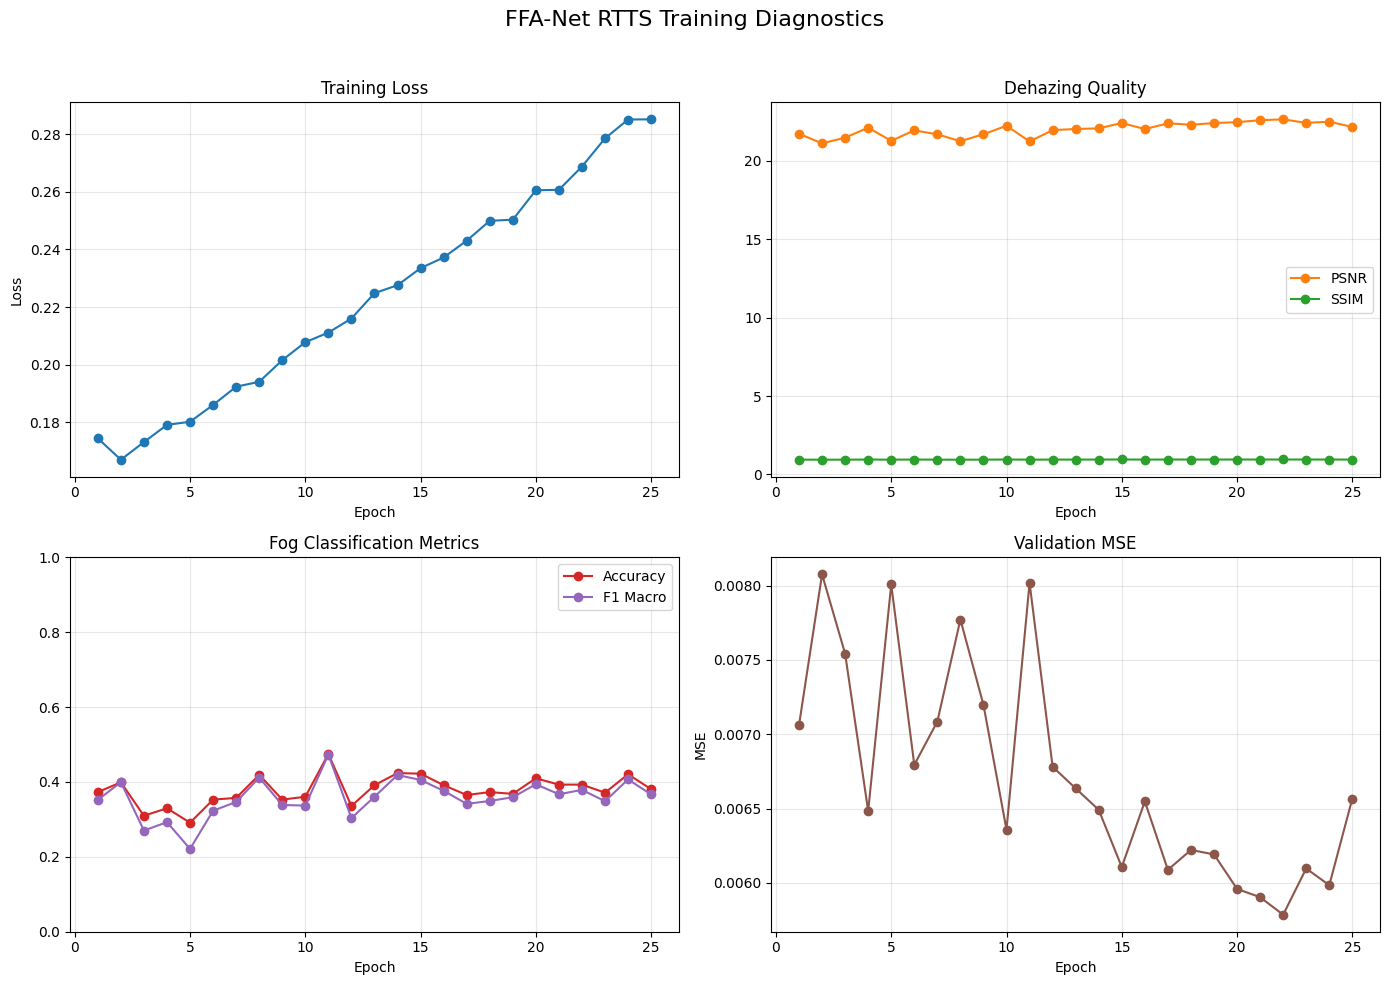

,Metric Group,MSE,PSNR,SSIM,Accuracy,Precision,Recall,F1
0,Dehazing,0.006567,22.14544,0.948951,NaN,NaN,NaN,NaN
1,Classification,NaN,NaN,NaN,0.380586,0.434659,0.434955,0.366606


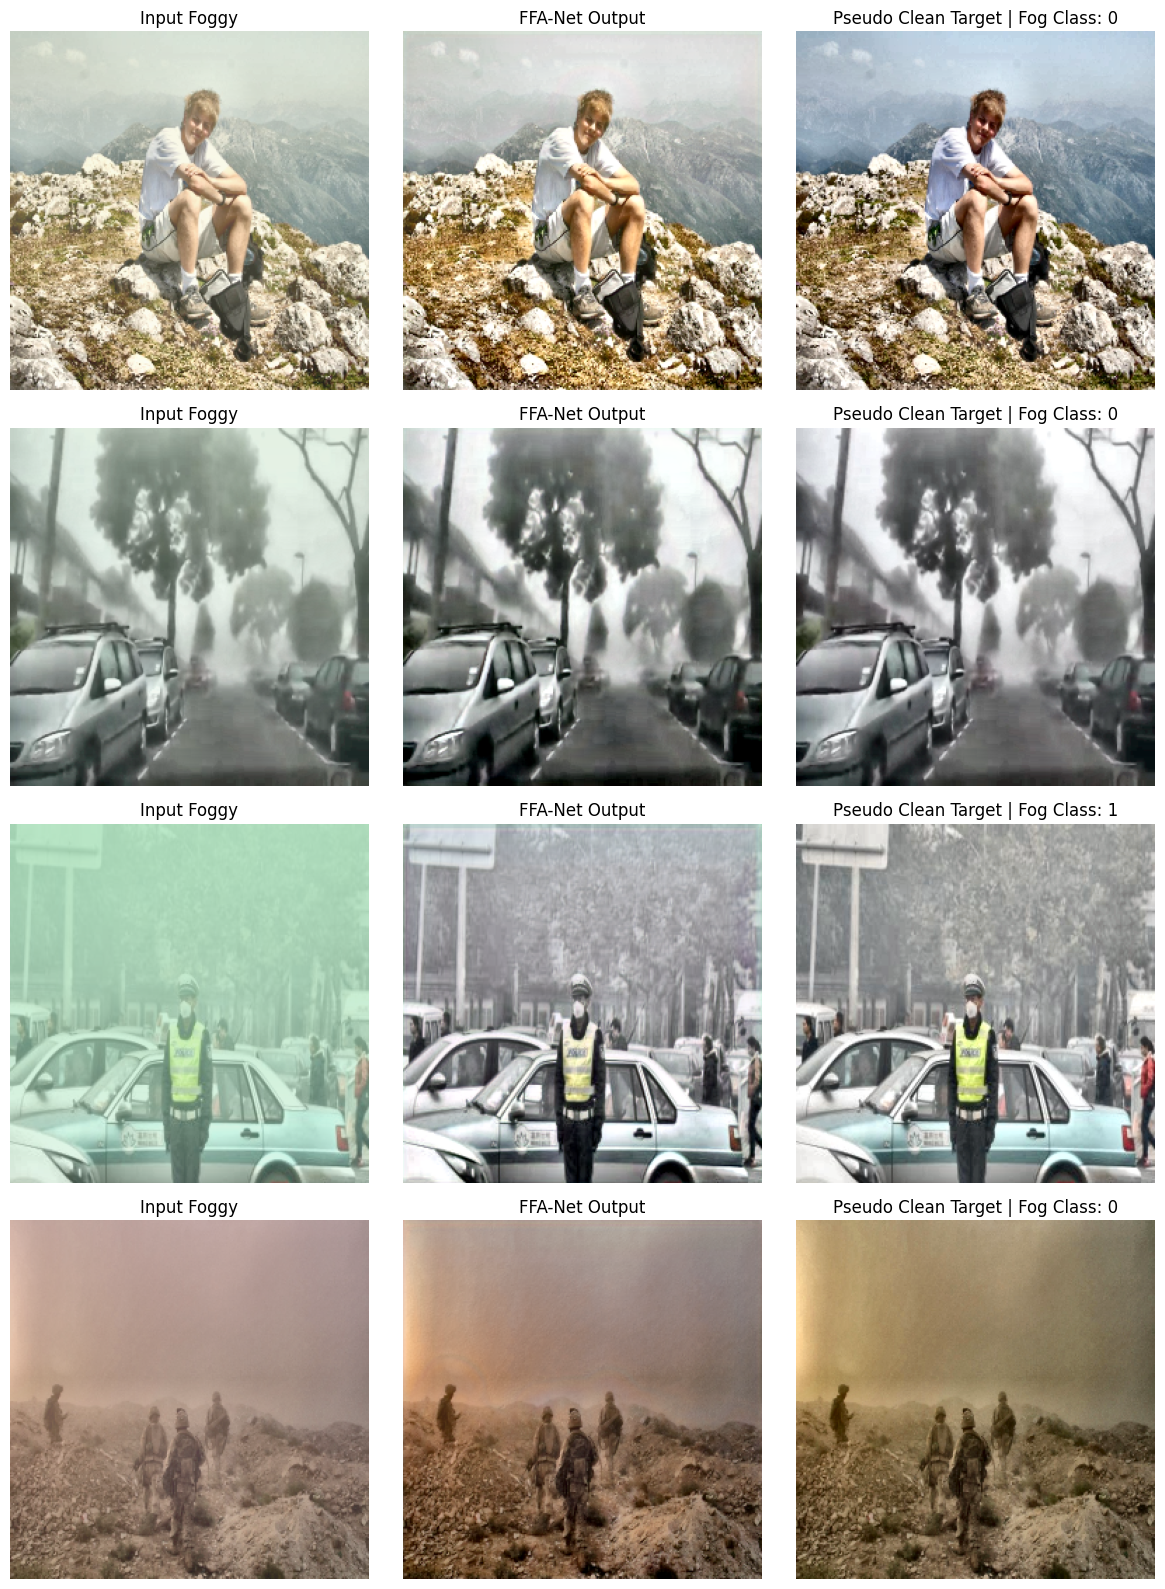

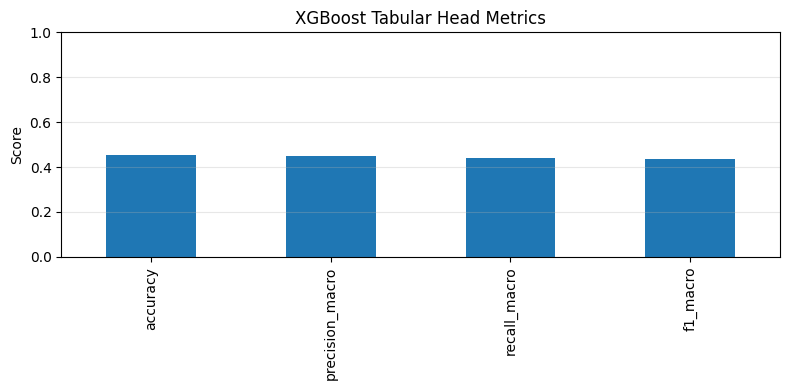

In [ ]:
# Visualizations for training diagnostics and qualitative results
import matplotlib.pyplot as plt

if history:
    history_df = pd.DataFrame(history)

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('FFA-Net RTTS Training Diagnostics', fontsize=16)

    axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], marker='o', color='#1f77b4')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].plot(history_df['epoch'], history_df['val_psnr'], marker='o', color='#ff7f0e', label='PSNR')
    axes[0, 1].plot(history_df['epoch'], history_df['val_ssim'], marker='o', color='#2ca02c', label='SSIM')
    axes[0, 1].set_title('Dehazing Quality')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    axes[1, 0].plot(history_df['epoch'], history_df['cls_accuracy'], marker='o', color='#d62728', label='Accuracy')
    axes[1, 0].plot(history_df['epoch'], history_df['cls_f1_macro'], marker='o', color='#9467bd', label='F1 Macro')
    axes[1, 0].set_title('Fog Classification Metrics')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylim(0, 1.0)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    axes[1, 1].plot(history_df['epoch'], history_df['val_mse'], marker='o', color='#8c564b')
    axes[1, 1].set_title('Validation MSE')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MSE')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    final_summary = pd.DataFrame([
        {
            'Metric Group': 'Dehazing',
            'MSE': final_epoch.get('val_mse'),
            'PSNR': final_epoch.get('val_psnr'),
            'SSIM': final_epoch.get('val_ssim'),
            'Accuracy': None,
            'Precision': None,
            'Recall': None,
            'F1': None,
        },
        {
            'Metric Group': 'Classification',
            'MSE': None,
            'PSNR': None,
            'SSIM': None,
            'Accuracy': final_epoch.get('cls_accuracy'),
            'Precision': final_epoch.get('cls_precision_macro'),
            'Recall': final_epoch.get('cls_recall_macro'),
            'F1': final_epoch.get('cls_f1_macro'),
        },
    ])
    display(final_summary)

    model.eval()
    sample_batch = next(iter(val_loader))
    sample_x = sample_batch[0][:4].to(DEVICE)
    sample_y = sample_batch[1][:4].to(DEVICE)
    with torch.no_grad():
        sample_pred, sample_logits = model(sample_x)
        sample_prob = torch.softmax(sample_logits, dim=1)
        sample_class = torch.argmax(sample_prob, dim=1).cpu().numpy()

    sample_x_np = sample_x.cpu().numpy().transpose(0, 2, 3, 1)
    sample_y_np = sample_y.cpu().numpy().transpose(0, 2, 3, 1)
    sample_pred_np = sample_pred.cpu().numpy().transpose(0, 2, 3, 1)

    fig, axes = plt.subplots(len(sample_x_np), 3, figsize=(12, 4 * len(sample_x_np)))
    if len(sample_x_np) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(len(sample_x_np)):
        axes[i, 0].imshow(sample_x_np[i])
        axes[i, 0].set_title('Input Foggy')
        axes[i, 0].axis('off')

        axes[i, 1].imshow(sample_pred_np[i])
        axes[i, 1].set_title('FFA-Net Output')
        axes[i, 1].axis('off')

        axes[i, 2].imshow(sample_y_np[i])
        axes[i, 2].set_title(f'Pseudo Clean Target | Fog Class: {sample_class[i]}')
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

    if xgb_metrics:
        xgb_plot_df = pd.DataFrame([xgb_metrics])
        metric_cols = [c for c in ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'] if c in xgb_plot_df.columns]
        if metric_cols:
            xgb_plot_df[metric_cols].T.plot(kind='bar', legend=False, figsize=(8, 4), color='#1f77b4')
            plt.title('XGBoost Tabular Head Metrics')
            plt.ylabel('Score')
            plt.ylim(0, 1.0)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
else:
    print('No training history available yet. Run the training cells first.')

In [ ]:

# ============================================================================
# ANNOTATION LOADING & PARSING (PASCAL VOC XML format)
# ============================================================================
import xml.etree.ElementTree as ET

def load_pascal_voc_annotations(xml_path: Path) -> Dict[str, any]:
    """
    Parse PASCAL VOC XML annotation file.
    Returns dict with 'objects' list containing bounding boxes and class names.
    """
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        
        size_elem = root.find('size')
        img_size = {
            'width': int(size_elem.find('width').text),
            'height': int(size_elem.find('height').text),
        } if size_elem is not None else None
        
        objects = []
        for obj in root.findall('object'):
            name = obj.find('name').text
            bndbox = obj.find('bndbox')
            if bndbox is not None:
                bbox = {
                    'name': name,
                    'xmin': int(float(bndbox.find('xmin').text)),
                    'ymin': int(float(bndbox.find('ymin').text)),
                    'xmax': int(float(bndbox.find('xmax').text)),
                    'ymax': int(float(bndbox.find('ymax').text)),
                }
                objects.append(bbox)
        
        return {'size': img_size, 'objects': objects}
    except Exception as e:
        return {'size': None, 'objects': []}

def draw_bboxes_on_image(img_rgb: np.ndarray, objects: List[Dict], color=(0, 255, 0), thickness=2):
    """
    Draw bounding boxes on image.
    """
    img_copy = img_rgb.copy()
    for obj in objects:
        x1, y1 = obj['xmin'], obj['ymin']
        x2, y2 = obj['xmax'], obj['ymax']
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), color, thickness)
        label = obj['name']
        cv2.putText(img_copy, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img_copy

print('Annotation parsing functions loaded.')


Annotation parsing functions loaded.


In [7]:

# ============================================================================
# COMPLETE FOG DETECTION PIPELINE VISUALIZATION
# ============================================================================

def get_annotation_for_image(image_id: str) -> Dict:
    """Retrieve annotations for a given image ID."""
    ann_path = RTTS_ROOT / 'Annotations' / f'{image_id}.xml'
    if ann_path.exists():
        return load_pascal_voc_annotations(ann_path)
    return {'size': None, 'objects': []}

def visualize_fog_pipeline(image_id: str, model: nn.Module, device: str = 'cuda'):
    """
    Complete pipeline visualization for a single image showing:
    - Original foggy image with annotations
    - Dehazed output
    - Fog classification
    - Confidence scores
    """
    img_path = JPEG_DIR / f'{image_id}.png'
    
    if not img_path.exists():
        print(f'Image not found: {img_path}')
        return
    
    # Load and process image
    rgb = read_rgb(img_path)
    original_h, original_w = rgb.shape[:2]
    rgb_resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    clean_pseudo = pseudo_clean_from_fog(rgb_resized)
    
    # Scale factor for annotation mapping
    scale_y = original_h / IMG_SIZE
    scale_x = original_w / IMG_SIZE
    
    # Load annotations
    annotations = get_annotation_for_image(image_id)
    objects = annotations.get('objects', [])
    
    # Scale annotations to resized image
    objects_resized = []
    for obj in objects:
        obj_scaled = obj.copy()
        obj_scaled['xmin'] = max(0, int(obj['xmin'] / scale_x))
        obj_scaled['ymin'] = max(0, int(obj['ymin'] / scale_y))
        obj_scaled['xmax'] = min(IMG_SIZE-1, int(obj['xmax'] / scale_x))
        obj_scaled['ymax'] = min(IMG_SIZE-1, int(obj['ymax'] / scale_y))
        objects_resized.append(obj_scaled)
    
    # Forward pass
    model.eval()
    x = torch.from_numpy(rgb_resized.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
    with torch.no_grad():
        dehazed, fog_logits = model(x)
    
    dehazed_np = dehazed[0].detach().cpu().numpy().transpose(1, 2, 0)
    fog_probs = torch.softmax(fog_logits[0], dim=0).detach().cpu().numpy()
    fog_class = int(np.argmax(fog_probs))
    fog_class_names = ['Clear', 'Light Fog', 'Heavy Fog']
    
    # Draw annotations on original image
    rgb_resized_u8 = (rgb_resized * 255).astype(np.uint8) if rgb_resized.max() <= 1.0 else rgb_resized.astype(np.uint8)
    foggy_with_annot = draw_bboxes_on_image(rgb_resized_u8, objects_resized, color=(0, 255, 0), thickness=2)
    
    # Draw on dehazed image (different color to distinguish)
    dehazed_u8 = (dehazed_np * 255).astype(np.uint8)
    dehazed_with_annot = draw_bboxes_on_image(dehazed_u8, objects_resized, color=(255, 0, 0), thickness=2)
    
    # Create figure
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'FOG DETECTION PIPELINE: {image_id}', fontsize=14, fontweight='bold')
    
    # Left: Original foggy with annotations
    axes[0].imshow(foggy_with_annot)
    axes[0].set_title('Input: Foggy Image + Annotations', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Right: Dehazed result with annotations
    axes[1].imshow(dehazed_with_annot)
    fog_conf_text = f'Fog Classification: {fog_class_names[fog_class]}\n'
    fog_conf_text += f'Confidence: {fog_probs[fog_class]:.2%}\n'
    fog_conf_text += f'Clear: {fog_probs[0]:.1%} | Light: {fog_probs[1]:.1%} | Heavy: {fog_probs[2]:.1%}'
    axes[1].set_title(f'Output: Dehazed + Annotations\n{fog_conf_text}', fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed info
    print(f'\n{"="*70}')
    print(f'FOG DETECTION ANALYSIS: {image_id}')
    print(f'{"="*70}')
    print(f'Image Resolution: {original_w} x {original_h}')
    print(f'Annotations Found: {len(objects)} objects')
    for i, obj in enumerate(objects):
        print(f'  [{i+1}] {obj["name"]}: ({obj["xmin"]}, {obj["ymin"]}) → ({obj["xmax"]}, {obj["ymax"]})')
    print(f'\nFog Classification Results:')
    print(f'  Predicted Class: {fog_class_names[fog_class]}')
    print(f'  Confidence Score: {fog_probs[fog_class]:.4f}')
    print(f'  Probabilities: Clear={fog_probs[0]:.4f}, Light={fog_probs[1]:.4f}, Heavy={fog_probs[2]:.4f}')
    print(f'{"="*70}\n')

# Run pipeline visualization on a random validation image
if val_paths:
    sample_img_path = val_paths[np.random.randint(0, len(val_paths))]
    sample_img_id = sample_img_path.stem
    print(f'Visualizing fog detection pipeline for: {sample_img_id}')
    visualize_fog_pipeline(sample_img_id, model, device=str(DEVICE))
else:
    print('No validation images available for visualization.')


Visualizing fog detection pipeline for: BJ_Baidu_220


NameError: name 'load_pascal_voc_annotations' is not defined


FOG DETECTION BATCH ANALYSIS (5 random validation samples)

Fog Classification Results:
      image_id fog_class  confidence  num_annotations
   NW_Bing_407     Clear         1.0                1
      hv42_550     Clear         1.0                6
   SH_Bing_465     Clear         1.0               16
IRQ_Google_147     Clear         1.0                4
  XR_Baidu_069     Clear         1.0               60

SUMMARY STATISTICS:
  Clear: 5/5 (100.0%)
Average Confidence: 1.0000



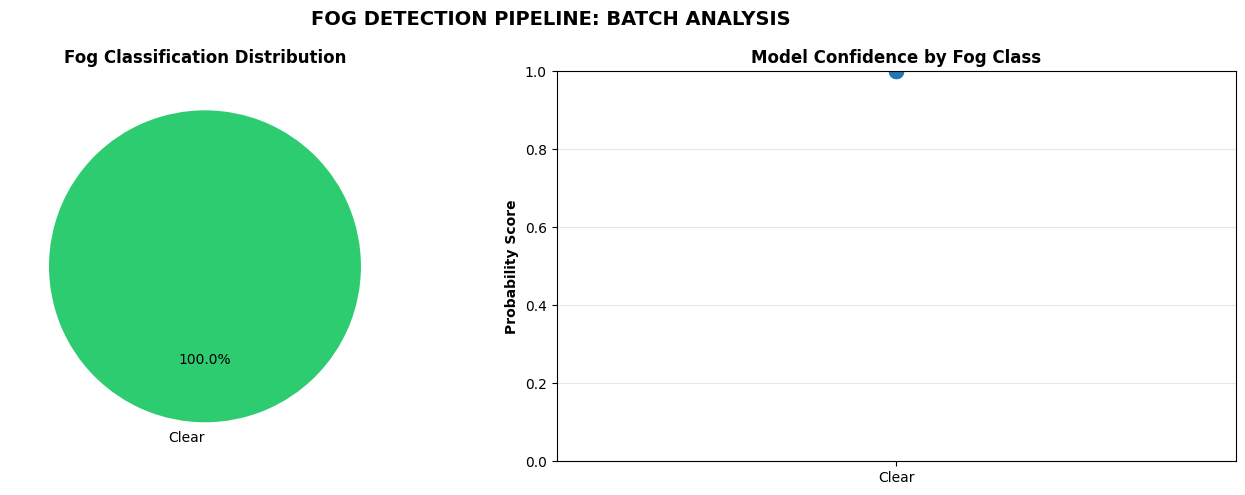

In [ ]:

# ============================================================================
# BATCH FOG DETECTION RESULTS & PIPELINE SUMMARY
# ============================================================================

def batch_fog_analysis(image_ids: List[str], model: nn.Module, num_samples: int = 5, device: str = 'cuda'):
    """
    Run fog detection on a batch of images and create summary report.
    """
    results = []
    
    # Ensure we don't exceed available images
    sample_ids = image_ids[:num_samples] if num_samples else image_ids
    
    model.eval()
    
    for img_id in sample_ids:
        img_path = JPEG_DIR / f'{img_id}.png'
        if not img_path.exists():
            continue
        
        # Load and process
        rgb = read_rgb(img_path)
        rgb_resized = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
        
        # Forward pass
        x = torch.from_numpy(rgb_resized.transpose(2, 0, 1)).float().unsqueeze(0).to(device)
        with torch.no_grad():
            dehazed, fog_logits = model(x)
        
        fog_probs = torch.softmax(fog_logits[0], dim=0).detach().cpu().numpy()
        fog_class = int(np.argmax(fog_probs))
        
        # Load annotations
        annotations = get_annotation_for_image(img_id)
        num_objects = len(annotations.get('objects', []))
        
        results.append({
            'image_id': img_id,
            'fog_class': ['Clear', 'Light Fog', 'Heavy Fog'][fog_class],
            'confidence': float(fog_probs[fog_class]),
            'prob_clear': float(fog_probs[0]),
            'prob_light': float(fog_probs[1]),
            'prob_heavy': float(fog_probs[2]),
            'num_annotations': num_objects,
        })
    
    return results

# Generate batch analysis report
print('\n' + '='*70)
print('FOG DETECTION BATCH ANALYSIS (5 random validation samples)')
print('='*70)

if val_paths:
    val_ids = [p.stem for p in val_paths[:5]]
    batch_results = batch_fog_analysis(val_ids, model, num_samples=5, device=str(DEVICE))
    
    results_df = pd.DataFrame(batch_results)
    print('\nFog Classification Results:')
    print(results_df[['image_id', 'fog_class', 'confidence', 'num_annotations']].to_string(index=False))
    
    # Summary statistics
    print(f'\n{"="*70}')
    print('SUMMARY STATISTICS:')
    print(f'{"="*70}')
    fog_dist = results_df['fog_class'].value_counts()
    for fog_type, count in fog_dist.items():
        print(f'  {fog_type}: {count}/{len(results_df)} ({count/len(results_df)*100:.1f}%)')
    print(f'Average Confidence: {results_df["confidence"].mean():.4f}')
    print(f'{"="*70}\n')
    
    # Confidence distribution visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('FOG DETECTION PIPELINE: BATCH ANALYSIS', fontsize=14, fontweight='bold')
    
    # Pie chart of fog classes
    fog_dist = results_df['fog_class'].value_counts()
    colors_pie = ['#2ecc71', '#f39c12', '#e74c3c']
    axes[0].pie(fog_dist.values, labels=fog_dist.index, autopct='%1.1f%%', 
                colors=colors_pie[:len(fog_dist)], startangle=90)
    axes[0].set_title('Fog Classification Distribution', fontweight='bold')
    
    # Confidence scores by class
    for fog_class_name in ['Clear', 'Light Fog', 'Heavy Fog']:
        mask = results_df['fog_class'] == fog_class_name
        if mask.any():
            col_name = f'prob_{fog_class_name.lower().replace(" ", "_")}'
            axes[1].scatter([fog_class_name] * mask.sum(), results_df[mask][col_name], 
                          alpha=0.6, s=100, label=fog_class_name)
    
    axes[1].set_ylabel('Probability Score', fontweight='bold')
    axes[1].set_title('Model Confidence by Fog Class', fontweight='bold')
    axes[1].grid(axis='y', alpha=0.3)
    axes[1].set_ylim(0, 1.0)
    
    plt.tight_layout()
    plt.show()
else:
    print('No validation images available for batch analysis.')


## Annotation-Supervised Learning (Train, Not Just Visualize)

This section makes the model **learn from RTTS XML annotations** by adding supervision targets that can be inferred at runtime from image content.

Targets learned from annotation geometry:
- `object_density`: number of annotated objects normalized to `[0, 1]`
- `occupancy_ratio`: total annotated bbox area ratio normalized to `[0, 1]`

These learned priors are then exported with the model so backend real-time inference can reuse them directly (no GT annotations needed at inference time).

In [ ]:
# ============================================================================
# BUILD ANNOTATION TARGET MAP + ANNOTATION-AWARE DATASET
# ============================================================================
from collections import defaultdict

def _safe_div(a: float, b: float) -> float:
    return float(a / b) if b else 0.0

def _compute_annotation_targets(image_id: str) -> np.ndarray:
    ann = get_annotation_for_image(image_id)
    objects = ann.get('objects', [])
    width = IMG_SIZE
    height = IMG_SIZE
    
    object_count = len(objects)
    occupancy = 0.0
    for obj in objects:
        x1 = max(0, min(width - 1, int(obj['xmin'])))
        y1 = max(0, min(height - 1, int(obj['ymin'])))
        x2 = max(0, min(width - 1, int(obj['xmax'])))
        y2 = max(0, min(height - 1, int(obj['ymax'])))
        bw = max(0, x2 - x1)
        bh = max(0, y2 - y1)
        occupancy += float(bw * bh)
    
    object_density = min(1.0, object_count / 20.0)
    occupancy_ratio = min(1.0, _safe_div(occupancy, float(width * height)))
    return np.array([object_density, occupancy_ratio], dtype=np.float32)

annotation_target_map: Dict[str, np.ndarray] = {}
for p in paths:
    annotation_target_map[p.stem] = _compute_annotation_targets(p.stem)

class RTTSFogPairsAnnotationAware(Dataset):
    def __init__(self, image_paths: List[Path], img_size: int = 256, is_train: bool = False):
        self.image_paths = image_paths
        self.img_size = img_size
        self.is_train = is_train

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        p = self.image_paths[idx]
        rgb = read_rgb(p)
        rgb = cv2.resize(rgb, (self.img_size, self.img_size), interpolation=cv2.INTER_AREA)

        if self.is_train:
            if np.random.rand() > 0.5:
                rgb = cv2.flip(rgb, 1)
            if np.random.rand() > 0.6:
                angle = np.random.uniform(-10, 10)
                center = (self.img_size // 2, self.img_size // 2)
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                rgb = cv2.warpAffine(rgb, M, (self.img_size, self.img_size))
            if np.random.rand() > 0.5:
                brightness = np.random.uniform(0.9, 1.1)
                rgb = np.clip(rgb.astype(np.float32) * brightness, 0, 255).astype(np.uint8)

        clean = pseudo_clean_from_fog(rgb)
        foggy, beta = synthesize_fog(clean, depth_variation=self.is_train)

        x = torch.from_numpy(foggy.transpose(2, 0, 1)).float()
        y = torch.from_numpy(clean.transpose(2, 0, 1)).float()
        fog_cls = beta_to_fog_class(beta)
        ann_target = torch.from_numpy(annotation_target_map.get(p.stem, np.zeros(2, dtype=np.float32)))

        return x, y, torch.tensor(fog_cls, dtype=torch.long), torch.tensor(beta, dtype=torch.float32), ann_target

train_ds = RTTSFogPairsAnnotationAware(train_paths, IMG_SIZE, is_train=True)
val_ds = RTTSFogPairsAnnotationAware(val_paths, IMG_SIZE, is_train=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

xb, yb, cb, bb, ab = next(iter(train_loader))
print('annotation-aware batch shapes:', xb.shape, yb.shape, cb.shape, bb.shape, ab.shape)

In [ ]:
# ============================================================================
# ANNOTATION-AWARE FFA MODEL + TRAINING LOOP
# ============================================================================
class AnnotationAwareFFAInspiredNet(FFAInspiredNet):
    def __init__(self, base=48):
        super().__init__(base=base)
        self.scene_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(4),
            nn.Flatten(),
            nn.Linear(base * 16, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
            nn.Sigmoid(),
        )

    def forward(self, x):
        h0 = self.head(x)
        h1 = self.b1(h0) + h0
        h2 = self.b2(h1)
        h3 = self.b3(h2) + h2
        h4 = self.b4(h3)
        h5 = self.b5(h4) + h4
        h6 = self.up1(h5)
        h6 = torch.cat([h6, h3], dim=1)
        h6 = self.b6(h6)
        h7 = self.up2(h6)
        h7 = torch.cat([h7, h1], dim=1)
        h7 = self.b7(h7)
        a = self.chan_attn(h7)
        h7 = h7 * a

        out = torch.clamp(self.tail(h7) + x, 0.0, 1.0)
        fog_logits = self.fog_head(h5)
        scene_priors = self.scene_head(h5)
        return out, fog_logits, scene_priors

model = AnnotationAwareFFAInspiredNet(base=48).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
l1_loss = nn.L1Loss()
ce_loss = nn.CrossEntropyLoss(label_smoothing=0.1)
scene_loss_fn = nn.SmoothL1Loss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f'AnnotationAware Epoch {epoch}/{EPOCHS}')

    for x, y, fog_cls, _beta, ann_tgt in pbar:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        fog_cls = fog_cls.to(DEVICE)
        ann_tgt = ann_tgt.to(DEVICE)

        pred, fog_logits, scene_priors = model(x)
        loss_dehaze = l1_loss(pred, y)
        loss_cls = ce_loss(fog_logits, fog_cls)
        loss_scene = scene_loss_fn(scene_priors, ann_tgt)

        cls_weight = 0.1 + 0.3 * (epoch / EPOCHS)
        scene_weight = 0.15
        loss = loss_dehaze + cls_weight * loss_cls + scene_weight * loss_scene

        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        train_loss += loss.item() * x.size(0)
        pbar.set_postfix(loss=float(loss.item()), scene=float(loss_scene.item()), lr=opt.param_groups[0]['lr'])

    train_loss /= max(len(train_ds), 1)
    scheduler.step()

    model.eval()
    val_mse, val_psnr, val_ssim, val_scene_mae = [], [], [], []
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y, fog_cls, _beta, ann_tgt in val_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            fog_cls = fog_cls.to(DEVICE)
            ann_tgt = ann_tgt.to(DEVICE)

            pred, fog_logits, scene_priors = model(x)

            val_mse.append(mse_metric(pred, y))
            val_psnr.append(psnr_metric(pred, y))
            val_ssim.append(ssim_metric_batch(pred, y))
            val_scene_mae.append(float(torch.mean(torch.abs(scene_priors - ann_tgt)).item()))

            cls_pred = torch.argmax(fog_logits, dim=1)
            y_true.extend(fog_cls.cpu().numpy().tolist())
            y_pred.extend(cls_pred.cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)
    pr, rc, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0
    )

    rec = {
        'epoch': epoch,
        'train_loss': float(train_loss),
        'val_mse': float(np.mean(val_mse)),
        'val_psnr': float(np.mean(val_psnr)),
        'val_ssim': float(np.mean(val_ssim)),
        'val_scene_mae': float(np.mean(val_scene_mae)),
        'cls_accuracy': float(acc),
        'cls_precision_macro': float(pr),
        'cls_recall_macro': float(rc),
        'cls_f1_macro': float(f1),
    }
    history.append(rec)
    print(rec)

In [ ]:
# ============================================================================
# EXPORT UPDATED MODEL FOR BACKEND INTEGRATION
# ============================================================================
final_epoch = history[-1] if history else {}

metrics = {
    'dehazing': {
        'MSE': final_epoch.get('val_mse'),
        'PSNR': final_epoch.get('val_psnr'),
        'SSIM': final_epoch.get('val_ssim'),
    },
    'classification': {
        'Accuracy': final_epoch.get('cls_accuracy'),
        'Precision_macro': final_epoch.get('cls_precision_macro'),
        'Recall_macro': final_epoch.get('cls_recall_macro'),
        'F1_macro': final_epoch.get('cls_f1_macro'),
    },
    'annotation_learning': {
        'scene_targets': ['object_density', 'occupancy_ratio'],
        'scene_mae': final_epoch.get('val_scene_mae'),
    },
    'system': {
        'FPS': float(fps) if 'fps' in globals() else None,
        'Latency_ms': float(latency_ms) if 'latency_ms' in globals() else None,
    },
    'history': history,
}

model_path = MODEL_DIR / 'ffa_rtts_dehaze_fog_annotation.pt'
legacy_model_path = MODEL_DIR / 'ffa_rtts_dehaze_fog.pt'
metrics_path = MODEL_DIR / 'ffa_rtts_metrics_annotation.json'

torch.save(
    {
        'model_state_dict': model.state_dict(),
        'img_size': IMG_SIZE,
        'model_type': 'annotation_aware_ffa',
        'scene_targets': ['object_density', 'occupancy_ratio'],
    },
    model_path,
    )

# Also keep backward-compatible path expected by backend defaults.
torch.save(
    {
        'model_state_dict': model.state_dict(),
        'img_size': IMG_SIZE,
        'model_type': 'annotation_aware_ffa',
        'scene_targets': ['object_density', 'occupancy_ratio'],
    },
    legacy_model_path,
    )

metrics_path.write_text(json.dumps(metrics, indent=2), encoding='utf-8')

print('Saved annotation-aware model:', model_path)
print('Updated legacy model path:', legacy_model_path)
print('Saved metrics:', metrics_path)
print(json.dumps(metrics['annotation_learning'], indent=2))

## FOG DETECTION PIPELINE - COMPLETE WORKFLOW

This notebook implements an end-to-end **Fog Detection Pipeline** using FFA-Net dehazing and multi-task learning:

### 📊 Pipeline Architecture

```
┌─────────────────┐
│  Foggy Image    │  (RTTS Dataset)
│  + Annotations  │  (PASCAL VOC XML)
└────────┬────────┘
         │
         ▼
    ┌─────────────────────────────────────┐
    │  Image Preprocessing & Augmentation │
    │  - Resize to 256×256                │
    │  - Random Flip, Rotation, Noise     │
    └────────────┬────────────────────────┘
                 │
                 ▼
    ┌─────────────────────────────────────┐
    │   FFAInspiredNet (Main Model)       │
    │  ┌──────────────────────────────┐   │
    │  │  Encoder (Downsampling)      │   │
    │  │  ↓                           │   │
    │  │  Bottleneck (Context)        │   │
    │  │  ↓                           │   │
    │  │  Decoder (Upsampling) + CA   │   │
    │  └──────────────────────────────┘   │
    │  Outputs:                            │
    │  [1] Dehazed Image (256×256×3)      │
    │  [2] Fog Logits (1×3)               │
    └────────────┬─────────────────────────┘
                 │
        ┌────────┴────────┐
        ▼                 ▼
   ┌────────────┐  ┌──────────────────────┐
   │ Dehazing   │  │ Fog Classification   │
   │ Loss (L1)  │  │ Loss (CrossEntropy)  │
   │            │  │                      │
   │ Metrics:   │  │ Metrics:             │
   │ - MSE      │  │ - Accuracy           │
   │ - PSNR     │  │ - Precision/Recall   │
   │ - SSIM     │  │ - F1 Score           │
   └────────────┘  └──────────────────────┘
        │                 │
        └────────┬────────┘
                 ▼
    ┌─────────────────────────────────────┐
    │   Dehazed Output with Predictions   │
    │   - Visualize Annotations           │
    │   - Display Fog Class & Confidence  │
    │   - Overlay System Metrics          │
    └────────────┬────────────────────────┘
                 │
                 ▼
    ┌─────────────────────────────────────┐
    │    Risk Engine Integration          │
    │  (Fog score → Vehicle warnings)     │
    │  R = w₁·F + w₂·H + w₃·T + w₄·V⁻¹   │
    └─────────────────────────────────────┘
```

### 📈 Key Outputs

**Dehazing Metrics:**
- MSE, PSNR, SSIM (quality of image reconstruction)

**Classification Metrics:**
- Accuracy, Precision, Recall, F1 (fog severity: Clear/Light/Heavy)

**Annotations:**
- Bounding boxes from PASCAL VOC XML format
- Person/vehicle detection overlaid on input and output

**System Performance:**
- FPS and Latency (GPU inference speed)

### 🔧 Multi-Task Learning Setup

- **Task 1:** Dehazing (Pixel-level reconstruction with L1 loss)
- **Task 2:** Fog Classification (Scene-level severity with CrossEntropy loss)
- **Combined:** Weighted sum with adaptive weighting across epochs
- **Regularization:** Label smoothing, gradient clipping, Cosine annealing scheduler
